# 1 Kombinasi (0)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -196.208951
  B =    95.338229
  C =   -15.194278
  D =     0.783031
  R² = 0.994973

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.120658       0.127874     +5.98%
    186.00       0.357808       0.306228    -14.42%
    351.90       0.147901       0.177294    +19.87%
    662.00       0.036419       0.032879     -9.72%
   1173.00       0.007368       0.007236     -1.79%
   1332.00       0.005475       0.005679     +3.73%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


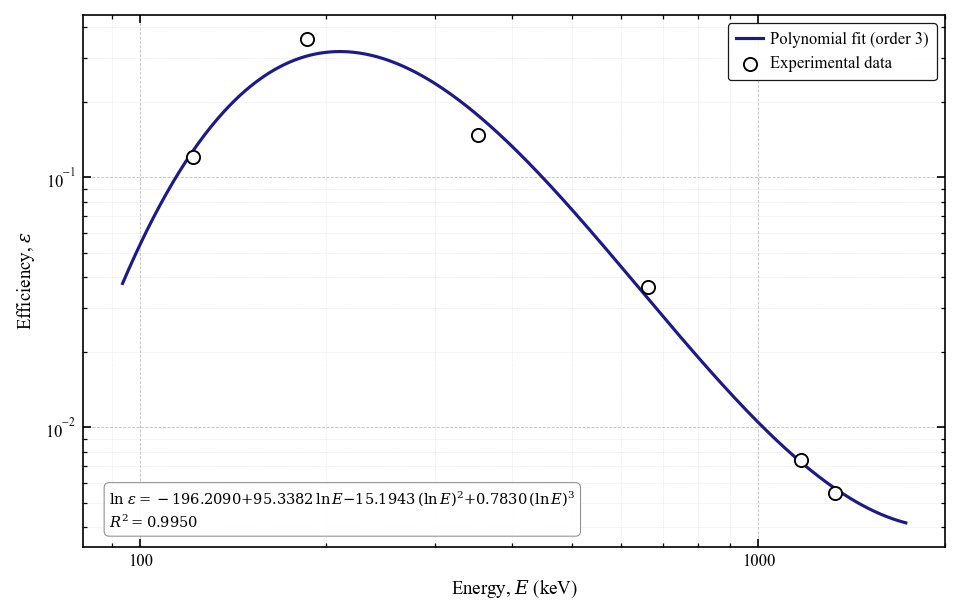


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.007236      3345.22
          1332         20.64   0.9998   0.005679      3634.95
-----------------------------------------------------------------
Aktivitas Co-60 = 3490.08 ± 144.86 Bq
               = 3.490 ± 0.145 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-196.208951$ |
| $B$ | $95.338229$ |
| $C$ | $-15.194278$ |
| $D$ | $0.783031$ |
| $R^2$ | $0.994973$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.128701 Co-57               
        186.00       0.306228 Ra-226              
        279.00       0.263646 Hg-203              
        356.00       0.173038 Ba-133              
        511.00       0.069713 Annihilasi          
        662.00       0.032879 Cs-137              
        834.00       0.016896 Mn-54               
       1173.00       0.007236 Co-60               
       1275.00       0.006138 Na-22               
       1332.00       0.005679 Co-60               


In [32]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.120658023,
                      0.357807849,
                      0.147900583,
                      0.036418719,
                      0.00736829,
                      0.005474929])



# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 2 Kombinasi (0)

HASIL FITTING POLINOMIAL ORDE 3
  A =    67.156831
  B =   -36.873269
  C =     6.590015
  D =    -0.398351
  R² = 0.962923

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.112567       0.127727    +13.47%
    186.00       0.125236       0.089099    -28.85%
    351.90       0.041287       0.061762    +49.59%
    662.00       0.039127       0.030796    -21.29%
   1173.00       0.007478       0.007437     -0.54%
   1332.00       0.004416       0.004672     +5.79%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


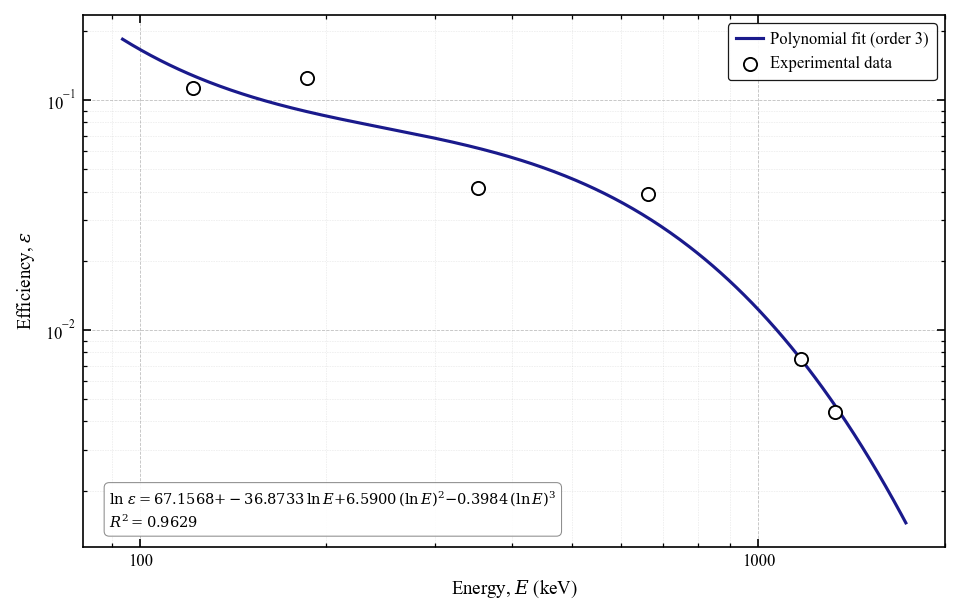


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.007437      3254.76
          1332         20.64   0.9998   0.004672      4418.75
-----------------------------------------------------------------
Aktivitas Co-60 = 3836.75 ± 581.99 Bq
               = 3.837 ± 0.582 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $67.156831$ |
| $B$ | $-36.873269$ |
| $C$ | $6.590015$ |
| $D$ | $-0.398351$ |
| $R^2$ | $0.962923$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.127465 Co-57               
        186.00       0.089099 Ra-226              
        279.00       0.071047 Hg-203              
        356.00       0.061275 Ba-133              
        511.00       0.044319 Annihilasi          
        662.00       0.030796 Cs-137              
        834.00       0.019516 Mn-54               
       1173.00       0.007437 Co-60               
       1275.00       0.005521 Na-22               
       1332.00       0.004672 Co-60               


In [33]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.112567348,
                      0.125235559,
                      0.041286752,
                      0.039126621,
                      0.007477884,
                      0.004416418])



# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 3 Kombinasi (0)

HASIL FITTING POLINOMIAL ORDE 3
  A =    51.127225
  B =   -30.956233
  C =     5.949016
  D =    -0.380175
  R² = 0.992496

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.082633       0.086990     +5.27%
    186.00       0.100368       0.087374    -12.95%
    351.90       0.070083       0.082623    +17.89%
    662.00       0.047815       0.043307     -9.43%
   1173.00       0.008965       0.008974     +0.10%
   1332.00       0.005214       0.005323     +2.08%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


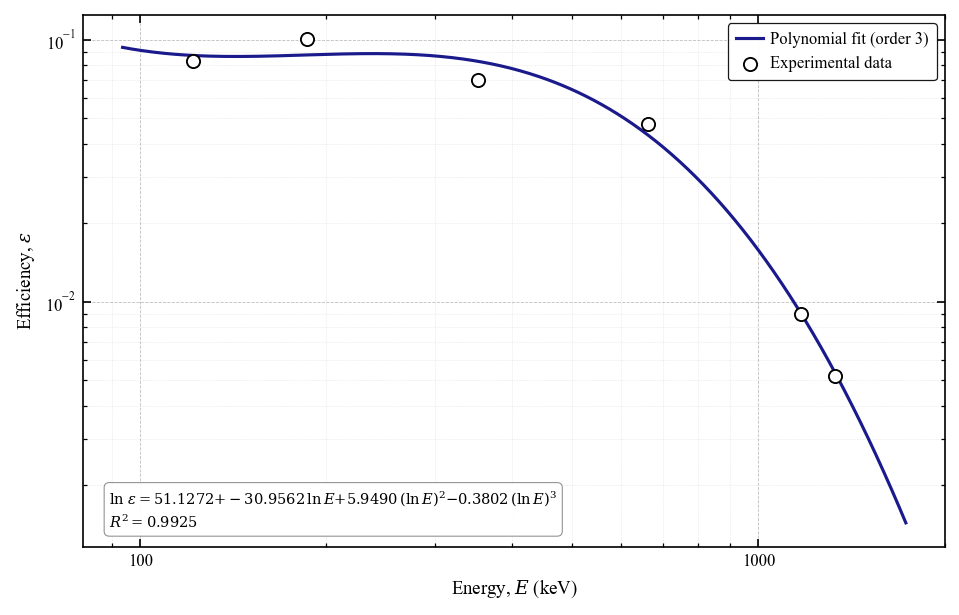


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.008974      2697.29
          1332         20.64   0.9998   0.005323      3878.47
-----------------------------------------------------------------
Aktivitas Co-60 = 3287.88 ± 590.59 Bq
               = 3.288 ± 0.591 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $51.127225$ |
| $B$ | $-30.956233$ |
| $C$ | $5.949016$ |
| $D$ | $-0.380175$ |
| $R^2$ | $0.992496$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.086971 Co-57               
        186.00       0.087374 Ra-226              
        279.00       0.087620 Hg-203              
        356.00       0.082229 Ba-133              
        511.00       0.062876 Annihilasi          
        662.00       0.043307 Cs-137              
        834.00       0.026359 Mn-54               
       1173.00       0.008974 Co-60               
       1275.00       0.006422 Na-22               
       1332.00       0.005323 Co-60               


In [34]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.082632946,
                      0.100367924,
                      0.070082686,
                      0.047814666,
                      0.008965089,
                      0.005214071])



# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 4 Kombinasi (0)

HASIL FITTING POLINOMIAL ORDE 3
  A =    21.269505
  B =   -15.807263
  C =     3.411131
  D =    -0.240233
  R² = 0.983906

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.069970       0.075777     +8.30%
    186.00       0.104988       0.084968    -19.07%
    351.90       0.060358       0.076678    +27.04%
    662.00       0.040723       0.036071    -11.42%
   1173.00       0.008172       0.007675     -6.08%
   1332.00       0.004383       0.004731     +7.95%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


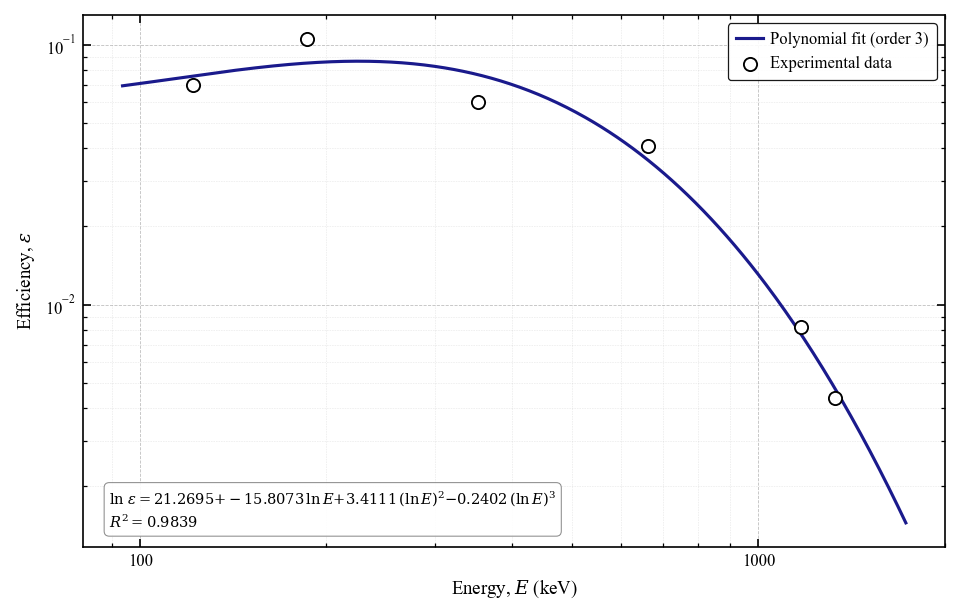


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.007675      3153.77
          1332         20.64   0.9998   0.004731      4363.60
-----------------------------------------------------------------
Aktivitas Co-60 = 3758.69 ± 604.91 Bq
               = 3.759 ± 0.605 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $21.269505$ |
| $B$ | $-15.807263$ |
| $C$ | $3.411131$ |
| $D$ | $-0.240233$ |
| $R^2$ | $0.983906$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.075823 Co-57               
        186.00       0.084968 Ra-226              
        279.00       0.084268 Hg-203              
        356.00       0.076154 Ba-133              
        511.00       0.054404 Annihilasi          
        662.00       0.036071 Cs-137              
        834.00       0.021670 Mn-54               
       1173.00       0.007675 Co-60               
       1275.00       0.005623 Na-22               
       1332.00       0.004731 Co-60               


In [2]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.069970447,
                      0.104987557,
                      0.060357553,
                      0.040722879,
                      0.008172007,
                      0.004382503])




# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 1 Kombinasi (45)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -190.412545
  B =    90.506564
  C =   -14.157604
  D =     0.714020
  R² = 0.988469

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.037477       0.040820     +8.92%
    186.00       0.141821       0.113671    -19.85%
    351.90       0.062923       0.079305    +26.03%
    662.00       0.016621       0.015353     -7.63%
   1173.00       0.003371       0.002849    -15.47%
   1332.00       0.001786       0.002079    +16.39%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


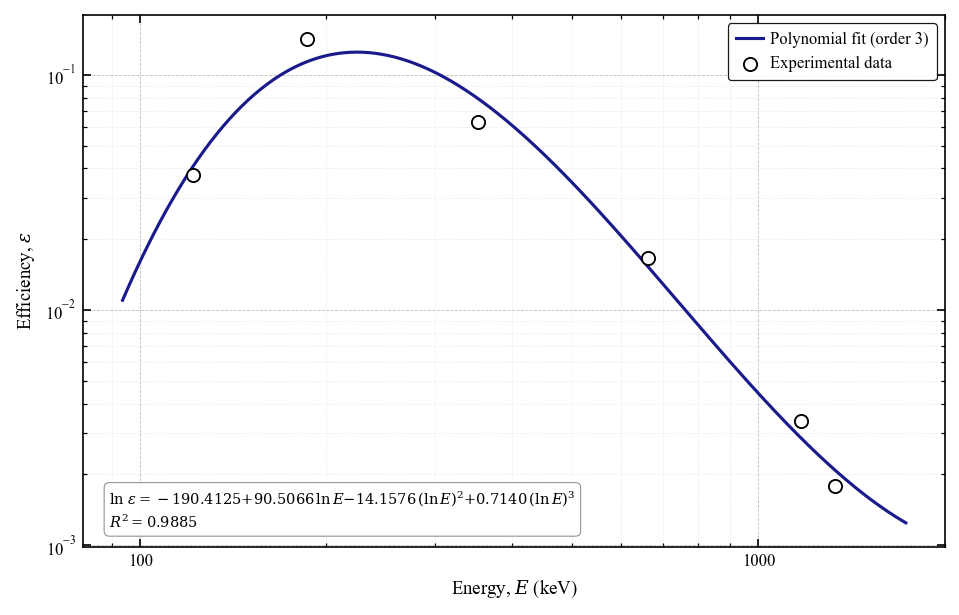


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.002849      8494.94
          1332         20.64   0.9998   0.002079      9930.15
-----------------------------------------------------------------
Aktivitas Co-60 = 9212.55 ± 717.61 Bq
               = 9.213 ± 0.718 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-190.412545$ |
| $B$ | $90.506564$ |
| $C$ | $-14.157604$ |
| $D$ | $0.714020$ |
| $R^2$ | $0.988469$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.041110 Co-57               
        186.00       0.113671 Ra-226              
        279.00       0.111411 Hg-203              
        356.00       0.077586 Ba-133              
        511.00       0.032755 Annihilasi          
        662.00       0.015353 Cs-137              
        834.00       0.007579 Mn-54               
       1173.00       0.002849 Co-60               
       1275.00       0.002308 Na-22               
       1332.00       0.002079 Co-60               


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.037476554,
                      0.141820916,
                      0.062923237,
                      0.016621328,
                      0.00337089259,
                      0.001786106])



# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 2 Kombinasi (45)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -161.820279
  B =    75.374622
  C =   -11.558005
  D =     0.568515
  R² = 0.981898

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.029042       0.032158    +10.73%
    186.00       0.114850       0.087904    -23.46%
    351.90       0.054098       0.072436    +33.90%
    662.00       0.019401       0.017092    -11.90%
   1173.00       0.003720       0.003245    -12.76%
   1332.00       0.001999       0.002292    +14.67%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


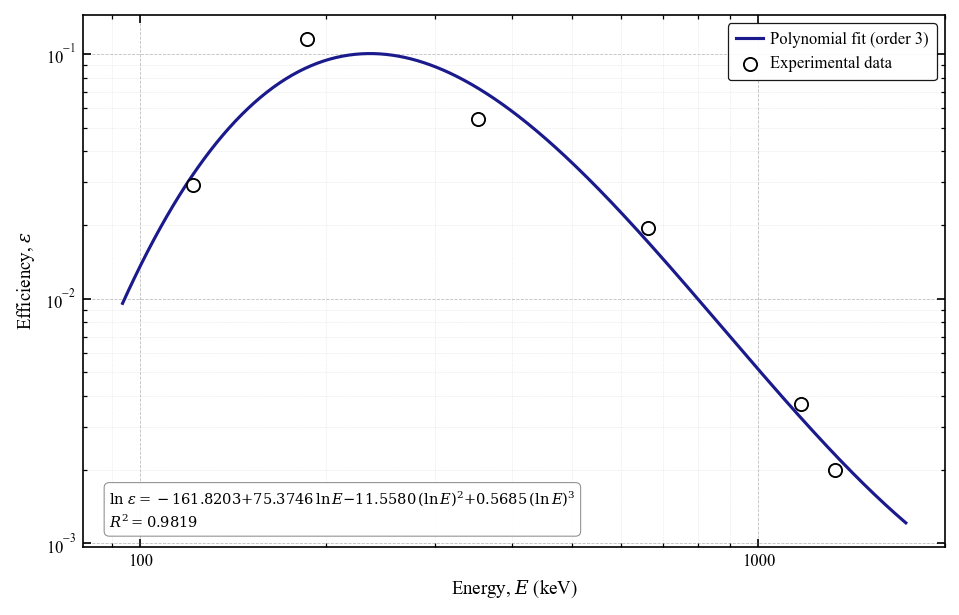


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.003245      7458.79
          1332         20.64   0.9998   0.002292      9005.34
-----------------------------------------------------------------
Aktivitas Co-60 = 8232.07 ± 773.28 Bq
               = 8.232 ± 0.773 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-161.820279$ |
| $B$ | $75.374622$ |
| $C$ | $-11.558005$ |
| $D$ | $0.568515$ |
| $R^2$ | $0.981898$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.032373 Co-57               
        186.00       0.087904 Ra-226              
        279.00       0.094286 Hg-203              
        356.00       0.071151 Ba-133              
        511.00       0.033971 Annihilasi          
        662.00       0.017092 Cs-137              
        834.00       0.008755 Mn-54               
       1173.00       0.003245 Co-60               
       1275.00       0.002578 Na-22               
       1332.00       0.002292 Co-60               


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.029041608,
                      0.11484982,
                      0.05409845,
                      0.019401256,
                      0.003720213,
                      0.0019992])

                     



# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 3 Kombinasi (45)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -129.669011
  B =    58.160170
  C =    -8.538918
  D =     0.394886
  R² = 0.987889

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.026254       0.028499     +8.55%
    186.00       0.095343       0.076529    -19.73%
    351.90       0.056680       0.073200    +29.15%
    662.00       0.022496       0.019482    -13.40%
   1173.00       0.003320       0.003233     -2.63%
   1332.00       0.001996       0.002104     +5.39%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


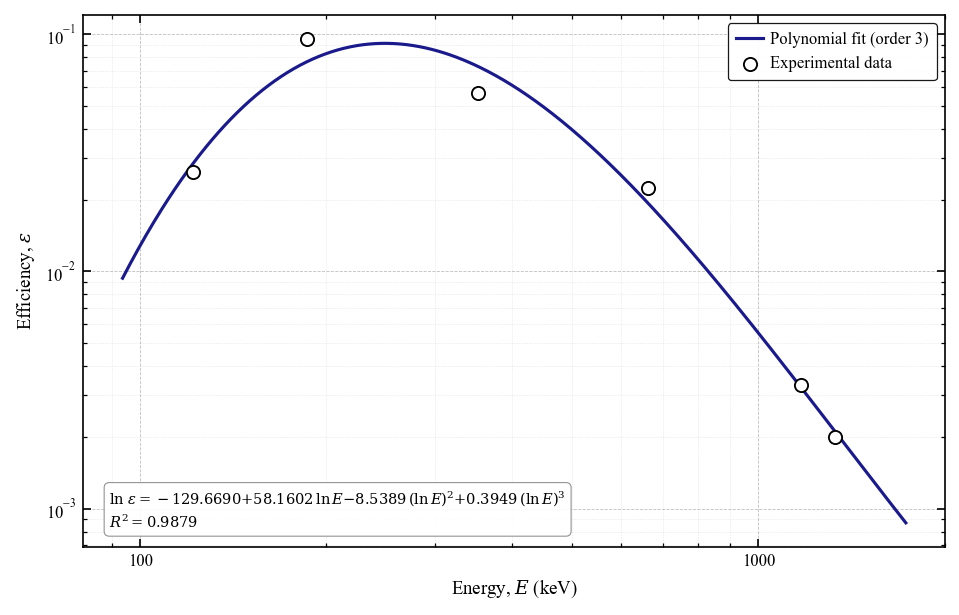


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.003233      7487.15
          1332         20.64   0.9998   0.002104      9811.23
-----------------------------------------------------------------
Aktivitas Co-60 = 8649.19 ± 1162.04 Bq
               = 8.649 ± 1.162 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-129.669011$ |
| $B$ | $58.160170$ |
| $C$ | $-8.538918$ |
| $D$ | $0.394886$ |
| $R^2$ | $0.987889$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.028678 Co-57               
        186.00       0.076529 Ra-226              
        279.00       0.089268 Hg-203              
        356.00       0.072136 Ba-133              
        511.00       0.037611 Annihilasi          
        662.00       0.019482 Cs-137              
        834.00       0.009834 Mn-54               
       1173.00       0.003233 Co-60               
       1275.00       0.002440 Na-22               
       1332.00       0.002104 Co-60               


In [4]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.026254406,
                      0.095343456,
                      0.056680296,
                      0.022496432,
                      0.003320361,
                      0.001996474])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 4 Kombinasi (45)

HASIL FITTING POLINOMIAL ORDE 3
  A =   -57.334431
  B =    21.478620
  C =    -2.411431
  D =     0.057413
  R² = 0.995438

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.030489       0.032005     +4.97%
    186.00       0.072736       0.063820    -12.26%
    351.90       0.056046       0.065423    +16.73%
    662.00       0.023874       0.021777     -8.79%
   1173.00       0.003302       0.003295     -0.21%
   1332.00       0.001902       0.001943     +2.18%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


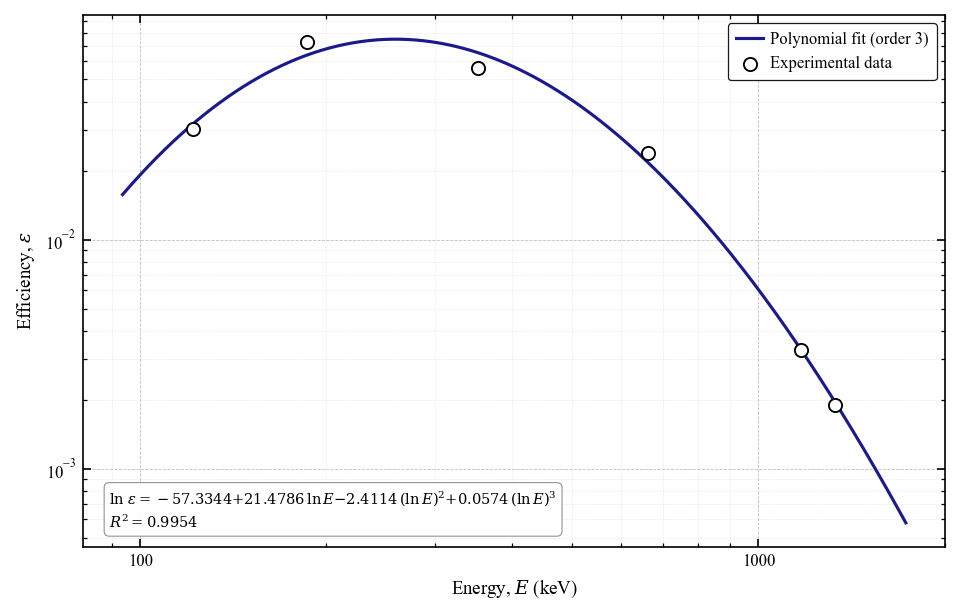


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.003295      7346.98
          1332         20.64   0.9998   0.001943     10624.45
-----------------------------------------------------------------
Aktivitas Co-60 = 8985.72 ± 1638.74 Bq
               = 8.986 ± 1.639 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-57.334431$ |
| $B$ | $21.478620$ |
| $C$ | $-2.411431$ |
| $D$ | $0.057413$ |
| $R^2$ | $0.995438$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.032137 Co-57               
        186.00       0.063820 Ra-226              
        279.00       0.074326 Hg-203              
        356.00       0.064749 Ba-133              
        511.00       0.038912 Annihilasi          
        662.00       0.021777 Cs-137              
        834.00       0.011207 Mn-54               
       1173.00       0.003295 Co-60               
       1275.00       0.002340 Na-22               
       1332.00       0.001943 Co-60               


In [6]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.030489076,
                      0.072735595,
                      0.056046395,
                      0.023874441,
                      0.003301549,
                      0.001901587])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 1 Kombinasi (90)

HASIL FITTING POLINOMIAL ORDE 3
  A =   -51.693158
  B =    21.431358
  C =    -2.891172
  D =     0.109683
  R² = 0.993459

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.035778       0.036795     +2.84%
    186.00       0.054167       0.049829     -8.01%
    351.90       0.031906       0.036173    +13.37%
    662.00       0.013800       0.012167    -11.83%
   1173.00       0.002328       0.002688    +15.45%
   1332.00       0.001986       0.001819     -8.41%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


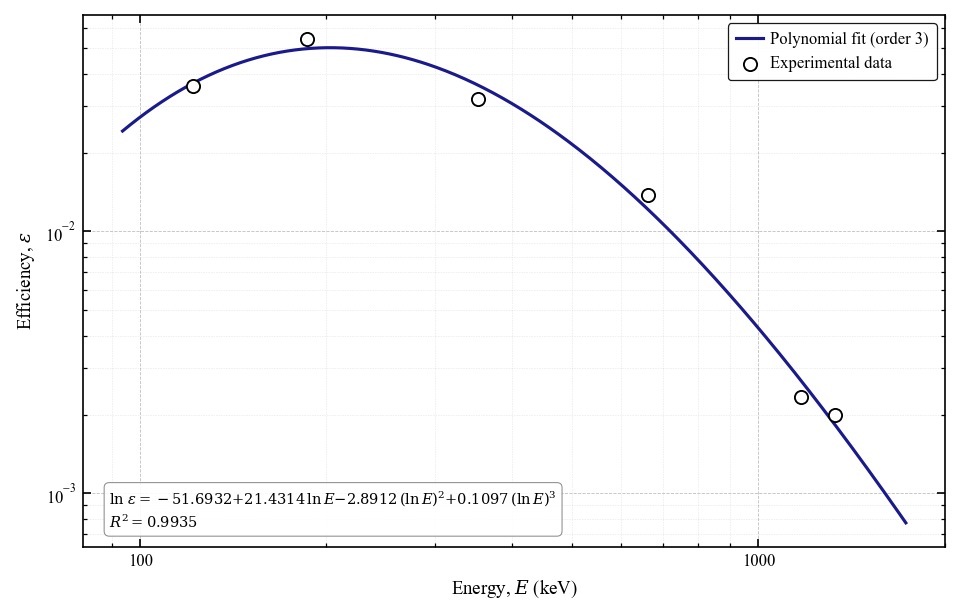


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.002688      9006.96
          1332         20.64   0.9998   0.001819     11347.46
-----------------------------------------------------------------
Aktivitas Co-60 = 10177.21 ± 1170.25 Bq
               = 10.177 ± 1.170 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-51.693158$ |
| $B$ | $21.431358$ |
| $C$ | $-2.891172$ |
| $D$ | $0.109683$ |
| $R^2$ | $0.993459$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.036878 Co-57               
        186.00       0.049829 Ra-226              
        279.00       0.044899 Hg-203              
        356.00       0.035685 Ba-133              
        511.00       0.020643 Annihilasi          
        662.00       0.012167 Cs-137              
        834.00       0.006969 Mn-54               
       1173.00       0.002688 Co-60               
       1275.00       0.002085 Na-22               
       1332.00       0.001819 Co-60               


In [37]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.035777857, 0.054167102, 0.031906068,
                      0.013799658, 0.002327842, 0.001986273])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 2 kombinasi (90)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -150.258862
  B =    70.837015
  C =   -11.030609
  D =     0.551619
  R² = 0.979123

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.030819       0.034217    +11.03%
    186.00       0.099329       0.074917    -24.58%
    351.90       0.037697       0.052663    +39.70%
    662.00       0.015597       0.012769    -18.13%
   1173.00       0.002853       0.002850     -0.09%
   1332.00       0.002029       0.002120     +4.51%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


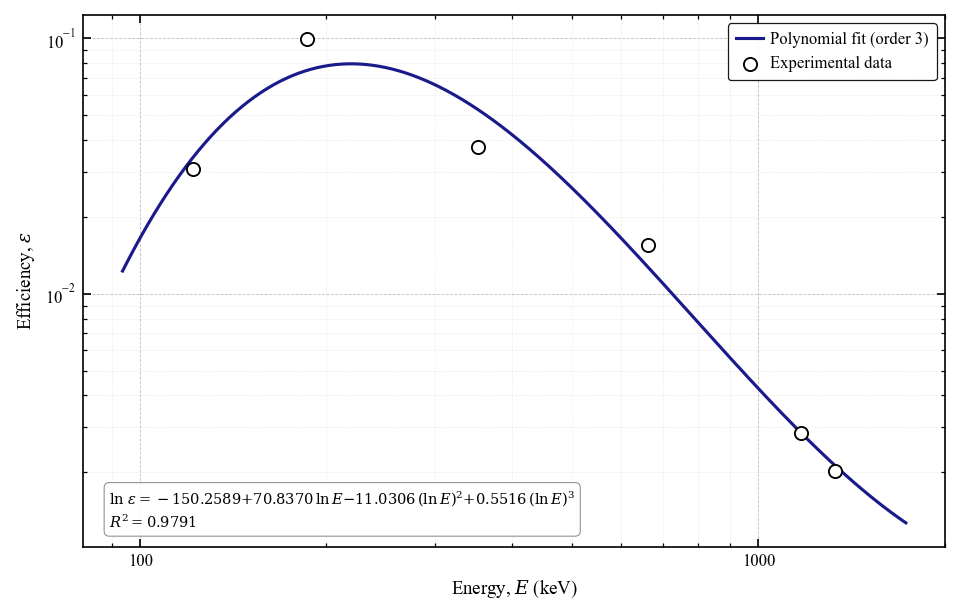


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.002850      8492.22
          1332         20.64   0.9998   0.002120      9736.83
-----------------------------------------------------------------
Aktivitas Co-60 = 9114.53 ± 622.31 Bq
               = 9.115 ± 0.622 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-150.258862$ |
| $B$ | $70.837015$ |
| $C$ | $-11.030609$ |
| $D$ | $0.551619$ |
| $R^2$ | $0.979123$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.034406 Co-57               
        186.00       0.074917 Ra-226              
        279.00       0.070977 Hg-203              
        356.00       0.051673 Ba-133              
        511.00       0.024587 Annihilasi          
        662.00       0.012769 Cs-137              
        834.00       0.006882 Mn-54               
       1173.00       0.002850 Co-60               
       1275.00       0.002341 Na-22               
       1332.00       0.002120 Co-60               


In [5]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.030818884, 0.099328844, 0.037697376,
                      0.015596656,0.002852995, 0.002028808])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 3 kombinasi (90)

HASIL FITTING POLINOMIAL ORDE 3
  A =  -167.129365
  B =    77.552177
  C =   -11.861372
  D =     0.582536
  R² = 0.964323

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.020762       0.023936    +15.28%
    186.00       0.103463       0.071015    -31.36%
    351.90       0.041111       0.062691    +52.49%
    662.00       0.018599       0.015131    -18.64%
   1173.00       0.003275       0.002871    -12.35%
   1332.00       0.001742       0.002025    +16.22%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


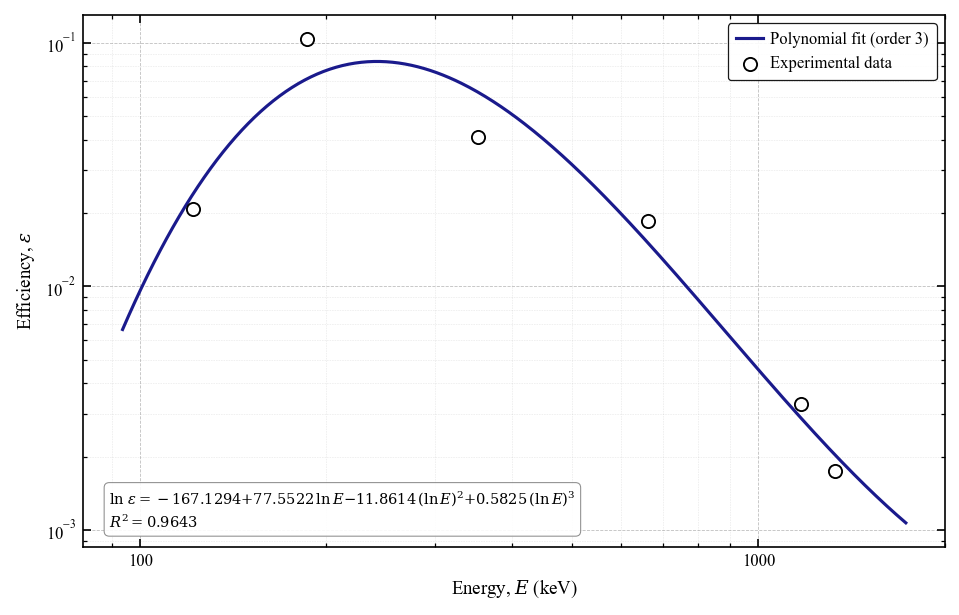


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.002871      8432.22
          1332         20.64   0.9998   0.002025     10193.68
-----------------------------------------------------------------
Aktivitas Co-60 = 9312.95 ± 880.73 Bq
               = 9.313 ± 0.881 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-167.129365$ |
| $B$ | $77.552177$ |
| $C$ | $-11.861372$ |
| $D$ | $0.582536$ |
| $R^2$ | $0.964323$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.024106 Co-57               
        186.00       0.071015 Ra-226              
        279.00       0.080099 Hg-203              
        356.00       0.061625 Ba-133              
        511.00       0.029920 Annihilasi          
        662.00       0.015131 Cs-137              
        834.00       0.007760 Mn-54               
       1173.00       0.002871 Co-60               
       1275.00       0.002278 Na-22               
       1332.00       0.002025 Co-60               


In [5]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.020762455,
                      0.103462673,
                      0.041110656,
                      0.018598882,
                      0.003275352,
                      0.00174248
                     ])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")


# 4 kombinasi (90)

HASIL FITTING POLINOMIAL ORDE 3
  A =   -82.840959
  B =    33.255719
  C =    -4.247736
  D =     0.153622
  R² = 0.985384

   E (keV)      ε terukur     ε prediksi  Error (%)
--------------------------------------------------
    121.78       0.015525       0.016820     +8.35%
    186.00       0.053857       0.043669    -18.92%
    351.90       0.043112       0.054092    +25.47%
    662.00       0.021254       0.019341     -9.00%
   1173.00       0.003593       0.003193    -11.14%
   1332.00       0.001736       0.001948    +12.19%
Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png


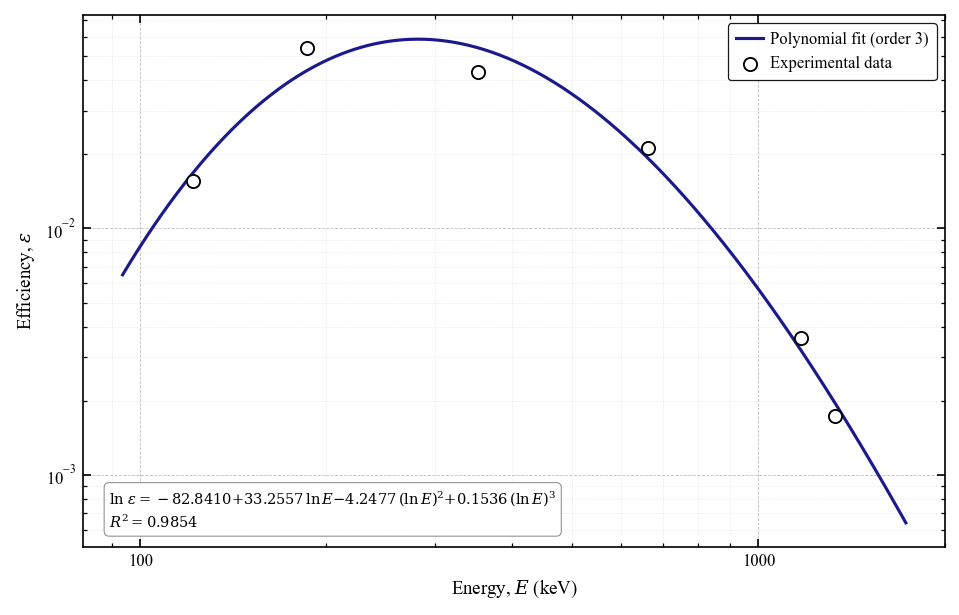


CONTOH PERHITUNGAN AKTIVITAS Co-60

  Energi (keV)   Cacah (cps)      I_γ          ε       A (Bq)
-----------------------------------------------------------------
          1173         24.17   0.9985   0.003193      7580.61
          1332         20.64   0.9998   0.001948     10599.27
-----------------------------------------------------------------
Aktivitas Co-60 = 9089.94 ± 1509.33 Bq
               = 9.090 ± 1.509 kBq


### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

| Parameter | Nilai |
|-----------|-------|
| $A$ | $-82.840959$ |
| $B$ | $33.255719$ |
| $C$ | $-4.247736$ |
| $D$ | $0.153622$ |
| $R^2$ | $0.985384$ |


TABEL LOOKUP EFISIENSI
  Energi (keV)      Efisiensi Sumber tipikal      
-------------------------------------------------------
         59.50   (luar range) Am-241              
         88.00   (luar range) Cd-109              
        122.00       0.016914 Co-57               
        186.00       0.043669 Ra-226              
        279.00       0.058604 Hg-203              
        356.00       0.053636 Ba-133              
        511.00       0.033715 Annihilasi          
        662.00       0.019341 Cs-137              
        834.00       0.010217 Mn-54               
       1173.00       0.003193 Co-60               
       1275.00       0.002317 Na-22               
       1332.00       0.001948 Co-60               


In [7]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================================
# BAGIAN 1: DATA KALIBRASI EFISIENSI
# ============================================================================

energi    = np.array([121.78, 186, 351.9, 662, 1173, 1332])     # keV
efisiensi = np.array([0.015524693, 0.053856727, 0.043111576,
                      0.021254172,0.003593371, 0.001736064])

# ============================================================================
# BAGIAN 2: FITTING POLINOMIAL ORDE 3
# ============================================================================

def fit_kalibrasi_efisiensi(E, eff, orde=3):
    ln_E   = np.log(E)
    ln_eff = np.log(eff)
    coeffs = np.polyfit(ln_E, ln_eff, orde)
    ln_eff_pred = np.polyval(coeffs, ln_E)
    ss_res = np.sum((ln_eff - ln_eff_pred) ** 2)
    ss_tot = np.sum((ln_eff - np.mean(ln_eff)) ** 2)
    r_sq   = 1 - ss_res / ss_tot
    return coeffs, r_sq

def hitung_efisiensi(E, coeffs):
    return np.exp(np.polyval(coeffs, np.log(E)))

coeffs, r_squared = fit_kalibrasi_efisiensi(energi, efisiensi, orde=3)
D, C, B, A = coeffs

print("=" * 70)
print("HASIL FITTING POLINOMIAL ORDE 3")
print("=" * 70)
print(f"  A = {A:>12.6f}")
print(f"  B = {B:>12.6f}")
print(f"  C = {C:>12.6f}")
print(f"  D = {D:>12.6f}")
print(f"  R² = {r_squared:.6f}")

print(f"\n{'E (keV)':>10} {'ε terukur':>14} {'ε prediksi':>14} {'Error (%)':>10}")
print("-" * 50)
for e, ef in zip(energi, efisiensi):
    ef_pred = hitung_efisiensi(e, coeffs)
    err     = (ef_pred - ef) / ef * 100
    print(f"{e:>10.2f} {ef:>14.6f} {ef_pred:>14.6f} {err:>+9.2f}%")

# ============================================================================
# BAGIAN 3: PLOT KALIBRASI — GAYA JURNAL
# ============================================================================

plt.rcParams.update({
    "font.family"       : "serif",
    "font.serif"        : ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset"  : "dejavuserif",
    "font.size"         : 9,
    "axes.titlesize"    : 9,
    "axes.labelsize"    : 9,
    "xtick.labelsize"   : 8,
    "ytick.labelsize"   : 8,
    "legend.fontsize"   : 8,
    "xtick.direction"   : "in",
    "ytick.direction"   : "in",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.minor.size"  : 2,
    "ytick.minor.size"  : 2,
    "xtick.top"         : True,
    "ytick.right"       : True,
    "axes.linewidth"    : 0.8,
    "lines.linewidth"   : 1.5,
    "figure.dpi"        : 150,
    "savefig.dpi"       : 600,
    "savefig.bbox"      : "tight",
})

# Lebar full-column jurnal: ~160 mm = 6.3 in
fig, ax = plt.subplots(figsize=(6.3, 4.0))

# --- Kurva fit ---------------------------------------------------------------
E_fit   = np.logspace(np.log10(energi.min() / 1.3),
                       np.log10(energi.max() * 1.3), 500)
eff_fit = hitung_efisiensi(E_fit, coeffs)

ax.plot(E_fit, eff_fit,
        color="#1a1a8c", linewidth=1.5, linestyle="-",
        label="Polynomial fit (order 3)", zorder=2)

# --- Data eksperimen ---------------------------------------------------------
ax.scatter(energi, efisiensi,
           s=40, color="white",
           edgecolor="black", linewidths=0.9,
           zorder=3, label="Experimental data")

# --- Skala log-log -----------------------------------------------------------
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x)}" if x >= 1 else f"{x:.1f}"))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

ax.yaxis.set_major_locator(LogLocator(base=10, numticks=6))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1,
                                       numticks=20))

# --- Grid halus --------------------------------------------------------------
ax.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.5)
ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, color="gray", alpha=0.3)

# --- Label sumbu -------------------------------------------------------------
ax.set_xlabel(r"Energy, $E$ (keV)")
ax.set_ylabel(r"Efficiency, $\varepsilon$")

# --- Legenda -----------------------------------------------------------------
legend = ax.legend(loc="upper right", frameon=True,
                   edgecolor="black", framealpha=0.9,
                   handlelength=1.6, handletextpad=0.4,
                   borderpad=0.5)
legend.get_frame().set_linewidth(0.6)

# --- Anotasi persamaan -------------------------------------------------------
eq_text = (
    r"$\ln\,\varepsilon = {:.4f}$".format(A) + 
    r"$+{:.4f}\,\ln E$".format(B) + 
    r"${:+.4f}\,(\ln E)^2$".format(C) + 
    r"${:+.4f}\,(\ln E)^3$".format(D) + "\n"
    r"$R^2 = {:.4f}$".format(r_squared)
)
ax.text(0.03, 0.03, eq_text,
        transform=ax.transAxes,
        fontsize=7, family="serif",
        verticalalignment="bottom",
        linespacing=1.4,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="gray",
                  linewidth=0.5, alpha=0.9))

plt.tight_layout(pad=0.4)

plt.savefig("kalibrasi_efisiensi_journal.pdf")
plt.savefig("kalibrasi_efisiensi_journal.png", dpi=600)
print("Grafik disimpan: kalibrasi_efisiensi_journal.pdf / .png")

plt.show()

# ============================================================================
# BAGIAN 4: PERHITUNGAN AKTIVITAS RADIONUKLIDA
# ============================================================================

def hitung_aktivitas(count_rate, energi_kev, branching_ratio, coeffs,
                     f_sum=1.0, f_att=1.0):
    eff = hitung_efisiensi(energi_kev, coeffs)
    A   = count_rate / (eff * branching_ratio * f_sum * f_att)
    return A, eff

print("\n" + "=" * 70)
print("CONTOH PERHITUNGAN AKTIVITAS Co-60")
print("=" * 70)

data_co60 = {
    "nama" : "Co-60",
    "peaks": [
        {"energi": 1173, "cps": 24.17, "I_gamma": 0.9985},
        {"energi": 1332, "cps": 20.64, "I_gamma": 0.9998},
    ],
}

print(f"\n{'Energi (keV)':>14} {'Cacah (cps)':>13} {'I_γ':>8} "
      f"{'ε':>10} {'A (Bq)':>12}")
print("-" * 65)

aktivitas_list = []
for peak in data_co60["peaks"]:
    A_val, eff = hitung_aktivitas(
        count_rate      = peak["cps"],
        energi_kev      = peak["energi"],
        branching_ratio = peak["I_gamma"],
        coeffs          = coeffs,
    )
    aktivitas_list.append(A_val)
    print(f"{peak['energi']:>14} {peak['cps']:>13.2f} "
          f"{peak['I_gamma']:>8.4f} {eff:>10.6f} {A_val:>12.2f}")

A_avg = np.mean(aktivitas_list)
A_std = np.std(aktivitas_list)
print("-" * 65)
print(f"Aktivitas Co-60 = {A_avg:.2f} ± {A_std:.2f} Bq")
print(f"               = {A_avg/1000:.3f} ± {A_std/1000:.3f} kBq")


from IPython.display import display, Math, Markdown

# Tampilkan persamaan kalibrasi dengan koefisien hasil fitting
display(Markdown("### Persamaan Kalibrasi Efisiensi Detektor NaI(Tl)"))

display(Math(
    r"\varepsilon(E) = \exp\!\Bigl("
    r"{A:.6f} "
    r"+ ({B:.6f})\,\ln E "
    r"+ ({C:.6f})\,(\ln E)^2 "
    r"+ ({D:.6f})\,(\ln E)^3"
    r"\Bigr)".format(A=A, B=B, C=C, D=D)
))

display(Math(r"R^2 = {:.6f}".format(r_squared)))

display(Markdown(
    f"| Parameter | Nilai |\n"
    f"|-----------|-------|\n"
    f"| $A$ | ${A:.6f}$ |\n"
    f"| $B$ | ${B:.6f}$ |\n"
    f"| $C$ | ${C:.6f}$ |\n"
    f"| $D$ | ${D:.6f}$ |\n"
    f"| $R^2$ | ${r_squared:.6f}$ |"
))


# ============================================================================
# BAGIAN 5: TABEL LOOKUP EFISIENSI
# ============================================================================
print("\n" + "=" * 70)
print("TABEL LOOKUP EFISIENSI")
print("=" * 70)
print(f"{'Energi (keV)':>14} {'Efisiensi':>14} {'Sumber tipikal':<20}")
print("-" * 55)

energi_umum = [
    (59.5,  "Am-241"),   (88,   "Cd-109"),
    (122,   "Co-57"),    (186,  "Ra-226"),
    (279,   "Hg-203"),   (356,  "Ba-133"),
    (511,   "Annihilasi"), (662, "Cs-137"),
    (834,   "Mn-54"),    (1173, "Co-60"),
    (1275,  "Na-22"),    (1332, "Co-60"),
]
for E, sumber in energi_umum:
    if energi.min() <= E <= energi.max():
        print(f"{E:>14.2f} {hitung_efisiensi(E, coeffs):>14.6f} {sumber:<20}")
    else:
        print(f"{E:>14.2f} {'(luar range)':>14} {sumber:<20}")
